In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from linearmodels.panel import PanelOLS, RandomEffects, PooledOLS
from scipy.stats import chi2, f
from statsmodels.stats.outliers_influence import variance_inflation_factor
from panel_utils import ModelResultsAggregator, run_panel_regressions, run_spec_tests


In [ ]:
###############################
# ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ
###############################
df_reg_analys = pd.read_excel('reg_analys.xlsx')
df_fed_analys = pd.read_excel('fed_analys.xlsx')


# Убираем служебные столбцы индекса
df_reg_analys = df_reg_analys.loc[:, ~df_reg_analys.columns.str.startswith('Unnamed')]
df_fed_analys = df_fed_analys.loc[:, ~df_fed_analys.columns.str.startswith('Unnamed')]

# Приводим даты к datetime
df_reg_analys['Date'] = pd.to_datetime(df_reg_analys['Date'])
df_fed_analys['Date'] = pd.to_datetime(df_fed_analys['Date'])

# Разделим Mon_Shock на позитивный и негативный
df_reg_analys['Mon_Shock_neg'] = df_reg_analys['Mon_Shock'].where(df_reg_analys['Mon_Shock'] < 0, 0)
df_reg_analys['Mon_Shock_pos'] = df_reg_analys['Mon_Shock'].where(df_reg_analys['Mon_Shock'] > 0, 0)

# Объединяем региональные и федеральные данные
fed_extra_cols = [
    col for col in df_fed_analys.columns
    if col not in df_reg_analys.columns and col != 'Region'
]
df_reg = df_reg_analys.merge(
    df_fed_analys[['Date'] + fed_extra_cols],
    on='Date',
    how='left'
)


# Взаимодействия (если требуется)
if 'Mon_Shock' in df_reg.columns and 'Cluster_1' in df_reg.columns:
    df_reg['Mon_Shock_Cl1'] = df_reg['Mon_Shock'] * df_reg['Cluster_1']
if 'Mon_Shock' in df_reg.columns and 'Cluster_2' in df_reg.columns:
    df_reg['Mon_Shock_Cl2'] = df_reg['Mon_Shock'] * df_reg['Cluster_2']
if 'Mon_Shock' in df_reg.columns and 'Covid_dum' in df_reg.columns:
    df_reg['Mon_Shock_Covid'] = df_reg['Mon_Shock'] * df_reg['Covid_dum']

# Кластерные выборки
if 'Cluster_1' in df_reg.columns and 'Cluster_2' in df_reg.columns:
    df_reg_clus_one = df_reg[df_reg['Cluster_1'] == 1].copy()
    df_reg_clus_two = df_reg[df_reg['Cluster_2'] == 1].copy()
    df_reg_clus_three = df_reg[(df_reg['Cluster_1'] == 0) & (df_reg['Cluster_2'] == 0)].copy()


In [86]:
###############################
# Построение линейных моделей на панельных данных (общая выборка)
# (d_Int_Rate_Mort зависимая переменная)
###############################

print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)")
print("Зависимая переменная: d_Int_Rate_Mort_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
    'd_ln_New_Loans_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum'
]

dependent_var = 'd_Int_Rate_Mort_adj'


# Создаем копию df_reg для работы
df_clean = df_reg.copy()  # Ð»Ð¾Ð³Ð¸ÐºÐ° Ð±ÐµÐ· Ð¸Ð·Ð¼ÐµÐ½ÐµÐ½Ð¸Ð¹

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
pooled_res, fe_res, re_res, pooled_success, fe_success, re_success = run_panel_regressions(
    y, X, cov_type='clustered', cluster_entity=True
)


ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)
Зависимая переменная: d_Int_Rate_Mort_adj

МОДЕЛЬ 1: POOLED OLS
                           PooledOLS Estimation Summary                          
Dep. Variable:     d_Int_Rate_Mort_adj   R-squared:                        0.1001
Estimator:                   PooledOLS   R-squared (Between):              0.3930
No. Observations:                 2812   R-squared (Within):               0.0991
Date:                  Ср, дек 24 2025   R-squared (Overall):              0.1001
Time:                         17:50:38   Log-likelihood                   -2658.3
Cov. Estimator:              Clustered                                           
                                         F-statistic:                      23.944
Entities:                           37   P-value                           0.0000
Avg Obs:                        76.000   Distribution:                 F(13,2799)
Min Obs:                        76.000                          

In [ ]:
# Сохраняем результаты модели для экспорта
pooled_res_1 = pooled_res if pooled_success else None
fe_res_1 = fe_res if fe_success else None
re_res_1 = re_res if re_success else None


In [87]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)


run_spec_tests(
    y, X, pooled_res, fe_res, re_res, pooled_success, fe_success, re_success
)



ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: -146.5750
p-значение: 1.000000
df: 13

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 1418.1350
p-значение: 0.000000
N (регионов): 37, T (периодов): 76

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -12.4528
p-значение: 1.000000
df: (36, 2762)

Вывод: p >= 0.05 - Pooled адекватна


In [88]:
# Добавляем результаты в сводную таблицу
aggregator_Int_Mort = ModelResultsAggregator()

aggregator_Int_Mort.add_model_results(
    re_res, 
    dependent_variable='d_Int_Rate_Mort_adj',
    subsample_name='Общая выборка',
    model_type='RE',
    specification_name='Модель_7',
    se_type = 'Clustered'
)

In [89]:
###############################
# Построение линейных моделей на панельных данных (общая выборка)
# (d_Int_Rate_Mort зависимая переменная)
###############################

print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)")
print("Зависимая переменная: d_Int_Rate_Mort_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
    'd_ln_New_Loans_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum',
    'Mon_Shock_Covid'
]

dependent_var = 'd_Int_Rate_Mort_adj'


# Создаем копию df_reg для работы
df_clean = df_reg.copy()  # Ð»Ð¾Ð³Ð¸ÐºÐ° Ð±ÐµÐ· Ð¸Ð·Ð¼ÐµÐ½ÐµÐ½Ð¸Ð¹

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
pooled_res, fe_res, re_res, pooled_success, fe_success, re_success = run_panel_regressions(
    y, X, cov_type='clustered', cluster_entity=True
)


ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)
Зависимая переменная: d_Int_Rate_Mort_adj

МОДЕЛЬ 1: POOLED OLS
                           PooledOLS Estimation Summary                          
Dep. Variable:     d_Int_Rate_Mort_adj   R-squared:                        0.1006
Estimator:                   PooledOLS   R-squared (Between):              0.4003
No. Observations:                 2812   R-squared (Within):               0.0995
Date:                  Ср, дек 24 2025   R-squared (Overall):              0.1006
Time:                         17:51:23   Log-likelihood                   -2657.5
Cov. Estimator:              Clustered                                           
                                         F-statistic:                      22.346
Entities:                           37   P-value                           0.0000
Avg Obs:                        76.000   Distribution:                 F(14,2798)
Min Obs:                        76.000                          

In [ ]:
# Сохраняем результаты модели для экспорта
pooled_res_2 = pooled_res if pooled_success else None
fe_res_2 = fe_res if fe_success else None
re_res_2 = re_res if re_success else None


In [90]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)


run_spec_tests(
    y, X, pooled_res, fe_res, re_res, pooled_success, fe_success, re_success
)



ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: -184.1317
p-значение: 1.000000
df: 14

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 1418.2112
p-значение: 0.000000
N (регионов): 37, T (периодов): 76

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -12.5891
p-значение: 1.000000
df: (36, 2761)

Вывод: p >= 0.05 - Pooled адекватна


In [91]:
# Добавляем результаты в сводную таблицу
aggregator_Int_Mort.add_model_results(
    re_res, 
    dependent_variable='d_Int_Rate_Mort_adj',
    subsample_name='Общая выборка',
    model_type='RE',
    specification_name='Модель_8',
    se_type = 'Clustered'
)

In [92]:
###############################
# Построение линейных моделей на панельных данных (общая выборка)
# (d_Int_Rate_Mort зависимая переменная)
###############################

print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)")
print("Зависимая переменная: d_Int_Rate_Mort_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
    'd_ln_New_Loans_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum',
    'Mon_Shock_Cl1',
    'Mon_Shock_Cl2'
]

dependent_var = 'd_Int_Rate_Mort_adj'


# Создаем копию df_reg для работы
df_clean = df_reg.copy()  # Ð»Ð¾Ð³Ð¸ÐºÐ° Ð±ÐµÐ· Ð¸Ð·Ð¼ÐµÐ½ÐµÐ½Ð¸Ð¹

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
pooled_res, fe_res, re_res, pooled_success, fe_success, re_success = run_panel_regressions(
    y, X, cov_type='clustered', cluster_entity=True
)


ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)
Зависимая переменная: d_Int_Rate_Mort_adj

МОДЕЛЬ 1: POOLED OLS
                           PooledOLS Estimation Summary                          
Dep. Variable:     d_Int_Rate_Mort_adj   R-squared:                        0.1001
Estimator:                   PooledOLS   R-squared (Between):              0.3968
No. Observations:                 2812   R-squared (Within):               0.0991
Date:                  Ср, дек 24 2025   R-squared (Overall):              0.1001
Time:                         17:51:44   Log-likelihood                   -2658.2
Cov. Estimator:              Clustered                                           
                                         F-statistic:                      20.751
Entities:                           37   P-value                           0.0000
Avg Obs:                        76.000   Distribution:                 F(15,2797)
Min Obs:                        76.000                          

In [ ]:
# Сохраняем результаты модели для экспорта
pooled_res_3 = pooled_res if pooled_success else None
fe_res_3 = fe_res if fe_success else None
re_res_3 = re_res if re_success else None


In [93]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)


run_spec_tests(
    y, X, pooled_res, fe_res, re_res, pooled_success, fe_success, re_success
)



ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: -197.8351
p-значение: 1.000000
df: 15

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 1418.1758
p-значение: 0.000000
N (регионов): 37, T (периодов): 76

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -12.4382
p-значение: 1.000000
df: (36, 2760)

Вывод: p >= 0.05 - Pooled адекватна


In [94]:
# Добавляем результаты в сводную таблицу
aggregator_Int_Mort.add_model_results(
    re_res, 
    dependent_variable='d_Int_Rate_Mort_adj',
    subsample_name='Общая выборка',
    model_type='RE',
    specification_name='Модель_9',
    se_type = 'Clustered'
)

In [95]:
###############################
# Построение линейных моделей на панельных данных (общая выборка)
# (d_Int_Rate_Mort зависимая переменная)
###############################

print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)")
print("Зависимая переменная: d_Int_Rate_Mort_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
    'd_ln_New_Loans_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'ln_New_Loans_Progr'
]

dependent_var = 'd_Int_Rate_Mort_adj'


# Создаем копию df_reg для работы
df_clean = df_reg.copy()  # Ð»Ð¾Ð³Ð¸ÐºÐ° Ð±ÐµÐ· Ð¸Ð·Ð¼ÐµÐ½ÐµÐ½Ð¸Ð¹

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
pooled_res, fe_res, re_res, pooled_success, fe_success, re_success = run_panel_regressions(
    y, X, cov_type='clustered', cluster_entity=True
)


ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)
Зависимая переменная: d_Int_Rate_Mort_adj

МОДЕЛЬ 1: POOLED OLS
                           PooledOLS Estimation Summary                          
Dep. Variable:     d_Int_Rate_Mort_adj   R-squared:                        0.2141
Estimator:                   PooledOLS   R-squared (Between):             -1.6611
No. Observations:                  703   R-squared (Within):               0.2192
Date:                  Ср, дек 24 2025   R-squared (Overall):              0.2141
Time:                         17:51:51   Log-likelihood                   -922.84
Cov. Estimator:              Clustered                                           
                                         F-statistic:                      15.689
Entities:                           37   P-value                           0.0000
Avg Obs:                        19.000   Distribution:                  F(12,691)
Min Obs:                        19.000                          

In [ ]:
# Сохраняем результаты модели для экспорта
pooled_res_4 = pooled_res if pooled_success else None
fe_res_4 = fe_res if fe_success else None
re_res_4 = re_res if re_success else None


In [96]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)


run_spec_tests(
    y, X, pooled_res, fe_res, re_res, pooled_success, fe_success, re_success
)



ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: -8.1335
p-значение: 1.000000
df: 12

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 364.2657
p-значение: 0.000000
N (регионов): 37, T (периодов): 19

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -0.2497
p-значение: 1.000000
df: (36, 654)

Вывод: p >= 0.05 - Pooled адекватна


In [97]:
# Добавляем результаты в сводную таблицу
aggregator_Int_Mort.add_model_results(
    fe_res, 
    dependent_variable='d_Int_Rate_Mort_adj',
    subsample_name='Общая выборка',
    model_type='FE',
    specification_name='Модель_10',
    se_type = 'Clustered'
)

In [98]:
###############################
# Построение линейных моделей на панельных данных (общая выборка)
# (d_Int_Rate_Mort зависимая переменная)
###############################

print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)")
print("Зависимая переменная: d_Int_Rate_Mort_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
    'd_ln_New_Loans_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'ln_New_Loans_Progr',
    'Mon_Shock_Cl1',
    'Mon_Shock_Cl2'
]

dependent_var = 'd_Int_Rate_Mort_adj'


# Создаем копию df_reg для работы
df_clean = df_reg.copy()  # Ð»Ð¾Ð³Ð¸ÐºÐ° Ð±ÐµÐ· Ð¸Ð·Ð¼ÐµÐ½ÐµÐ½Ð¸Ð¹

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
pooled_res, fe_res, re_res, pooled_success, fe_success, re_success = run_panel_regressions(
    y, X, cov_type='clustered', cluster_entity=True
)


ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)
Зависимая переменная: d_Int_Rate_Mort_adj

МОДЕЛЬ 1: POOLED OLS
                           PooledOLS Estimation Summary                          
Dep. Variable:     d_Int_Rate_Mort_adj   R-squared:                        0.2151
Estimator:                   PooledOLS   R-squared (Between):             -1.5905
No. Observations:                  703   R-squared (Within):               0.2200
Date:                  Ср, дек 24 2025   R-squared (Overall):              0.2151
Time:                         17:51:51   Log-likelihood                   -922.40
Cov. Estimator:              Clustered                                           
                                         F-statistic:                      13.487
Entities:                           37   P-value                           0.0000
Avg Obs:                        19.000   Distribution:                  F(14,689)
Min Obs:                        19.000                          

In [ ]:
# Сохраняем результаты модели для экспорта
pooled_res_5 = pooled_res if pooled_success else None
fe_res_5 = fe_res if fe_success else None
re_res_5 = re_res if re_success else None


In [99]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)


run_spec_tests(
    y, X, pooled_res, fe_res, re_res, pooled_success, fe_success, re_success
)



ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: -8.3484
p-значение: 1.000000
df: 14

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 364.4362
p-значение: 0.000000
N (регионов): 37, T (периодов): 19

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -0.2222
p-значение: 1.000000
df: (36, 652)

Вывод: p >= 0.05 - Pooled адекватна


In [102]:
# Добавляем результаты в сводную таблицу
aggregator_Int_Mort.add_model_results(
    fe_res, 
    dependent_variable='d_Int_Rate_Mort_adj',
    subsample_name='Общая выборка',
    model_type='FE',
    specification_name='Модель_11',
    se_type = 'Clustered'
)

In [113]:
full_table_Int_FL = aggregator_Int_FL.build_table(
    include_pvalues=True,
    decimals=3
)
print(full_table_Int_FL)

                                       Модель_1            Модель_2  \
Зависимая переменная          d_Int_Rate_FL_adj   d_Int_Rate_FL_adj   
d_Int_Rate_FL_lag1_adj         -0.149** (0.018)    -0.153** (0.015)   
d_Cred_nagr_adj                  -4.079 (0.276)      -2.260 (0.593)   
d_D_top5_rozn_adj              30.196** (0.016)   32.197*** (0.010)   
d_Fin_Dostup_adj                 0.142* (0.097)      0.143* (0.098)   
Credit_impulse_adj               -0.004 (0.456)      -0.005 (0.353)   
d_Cred_structure_adj         -29.265*** (0.001)  -27.880*** (0.001)   
d_Def_Zadolg_Fl_adj              -0.402 (0.140)      -0.402 (0.141)   
Mon_Shock                      2.989*** (0.000)    3.600*** (0.000)   
d_Bonds_Rate_Correct_5Y_adj   -0.419*** (0.010)    -0.414** (0.011)   
Inflation_Expectations_adj      0.006** (0.029)     0.007** (0.014)   
Covid_dum                        -0.024 (0.469)   -0.118*** (0.005)   
Sank_dum                       0.168*** (0.000)    0.157*** (0.000)   
Mon_Sh

In [114]:
full_table_Int_ConsCred = aggregator_Int_ConsCred.build_table(
    include_pvalues=True,
    decimals=3
)
print(full_table_Int_ConsCred)

                                             Модель_4  \
Зависимая переменная          d_Int_Rate_ConsCred_adj   
d_Int_Rate_ConsCred_lag1_adj         -0.131** (0.047)   
d_Cred_nagr_adj                         6.367 (0.576)   
d_D_top5_rozn_adj                      18.188 (0.120)   
d_Fin_Dostup_adj                     0.180*** (0.004)   
Credit_impulse_adj                     -0.010 (0.416)   
d_Cred_structure_adj                57.253*** (0.000)   
d_Def_Zadolg_ConsCred_adj           -0.701*** (0.000)   
Mon_Shock                           -1.511*** (0.001)   
d_Bonds_Rate_Correct_5Y_adj         -0.758*** (0.000)   
d_Exc_rate_adj                      -0.110*** (0.000)   
Inflation_Expectations_adj           0.121*** (0.000)   
Covid_dum                            -0.123** (0.012)   
Sank_dum                             0.157*** (0.000)   
Mon_Shock_Covid                                         
Mon_Shock_Cl1                                           
Mon_Shock_Cl2                  

In [115]:
full_table_Int_Mort = aggregator_Int_Mort.build_table(
    include_pvalues=True,
    decimals=3
)
print(full_table_Int_Mort)

                                        Модель_7             Модель_8  \
Зависимая переменная         d_Int_Rate_Mort_adj  d_Int_Rate_Mort_adj   
d_Int_Rate_Mort_lag1_adj       -0.272*** (0.000)    -0.272*** (0.000)   
d_Cred_nagr_adj                    0.944 (0.471)        1.275 (0.351)   
d_D_top5_rozn_adj                  2.736 (0.709)        3.264 (0.656)   
d_Fin_Dostup_adj                  -0.003 (0.945)       -0.003 (0.949)   
Credit_impulse_adj                0.005* (0.078)        0.005 (0.102)   
d_Cred_structure_adj           -13.676** (0.024)    -13.078** (0.034)   
d_Def_Zadolg_Mort_adj            -0.729* (0.077)      -0.719* (0.081)   
Mon_Shock                      -0.861*** (0.002)     -0.718** (0.041)   
d_Bonds_Rate_Correct_5Y_adj     -0.127** (0.040)     -0.124** (0.045)   
d_Exc_rate_adj                     0.003 (0.313)        0.004 (0.208)   
Inflation_Expectations_adj     -0.010*** (0.000)    -0.010*** (0.000)   
Covid_dum                         -0.003 (0.898)   

In [96]:
###############################
# ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - КЛАСТЕР 1
###############################
descriptive_df = df_reg_clus_one[[  # Ð»Ð¾Ð³Ð¸ÐºÐ° Ð±ÐµÐ· Ð¸Ð·Ð¼ÐµÐ½ÐµÐ½Ð¸Ð¹
    'd_Int_Rate_FL_adj',
    'd_Int_Rate_Mort_adj',
    'Credit_impulse_adj',
    'd_Int_Rate_ConsCred_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'd_Def_Zadolg_Mort_adj',
    'd_Def_Zadolg_ConsCred_adj',
    'd_ln_New_Loans_Fl_adj',         
    'd_ln_New_Loans_Mort_adj',       
    'd_ln_New_Loans_ConsCred_adj',   
    'Inflation_Expectations_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'Mon_Shock',
    'd_Exc_rate_adj',
    'Covid_dum',
    'Sank_dum'
]]

desc = descriptive_df.describe().round(3).T

medians = descriptive_df.median()
desc['median'] = medians.round(3)

desc = desc.rename(columns={
    'mean': 'Среднее',
    'median': 'Медиана',
    'std': 'ст. откл.',
    'min': 'Мин.',
    'max': 'Макс.',
})

print("\n" + "="*60)
print("ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - КЛАСТЕР 1")
print("="*60)
print(desc[['Среднее', 'Медиана', 'ст. откл.', 'Мин.', 'Макс.']])


ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - КЛАСТЕР 1
                             Среднее  Медиана  ст. откл.    Мин.   Макс.
d_Int_Rate_FL_adj              0.079   -0.038      1.069 -13.724  13.319
d_Int_Rate_Mort_adj           -0.034   -0.042      0.677  -4.479   5.582
Credit_impulse_adj            -0.630   -0.032      7.268 -55.926  56.097
d_Int_Rate_ConsCred_adj        0.182    0.032      1.298 -16.410  21.073
d_Cred_nagr_adj               -0.001    0.000      0.010  -0.059   0.037
d_D_top5_rozn_adj              0.001    0.001      0.003  -0.024   0.036
d_Fin_Dostup_adj              -0.042   -0.023      0.260  -5.750   3.483
d_Cred_structure_adj           0.001    0.001      0.003  -0.022   0.021
d_Def_Zadolg_Fl_adj            0.006   -0.009      0.098  -0.834   1.286
d_Def_Zadolg_Mort_adj          0.000   -0.004      0.045  -0.584   0.544
d_Def_Zadolg_ConsCred_adj      0.030    0.002      0.175  -1.049   2.716
d_ln_New_Loans_Fl_adj          0.007    0.021    

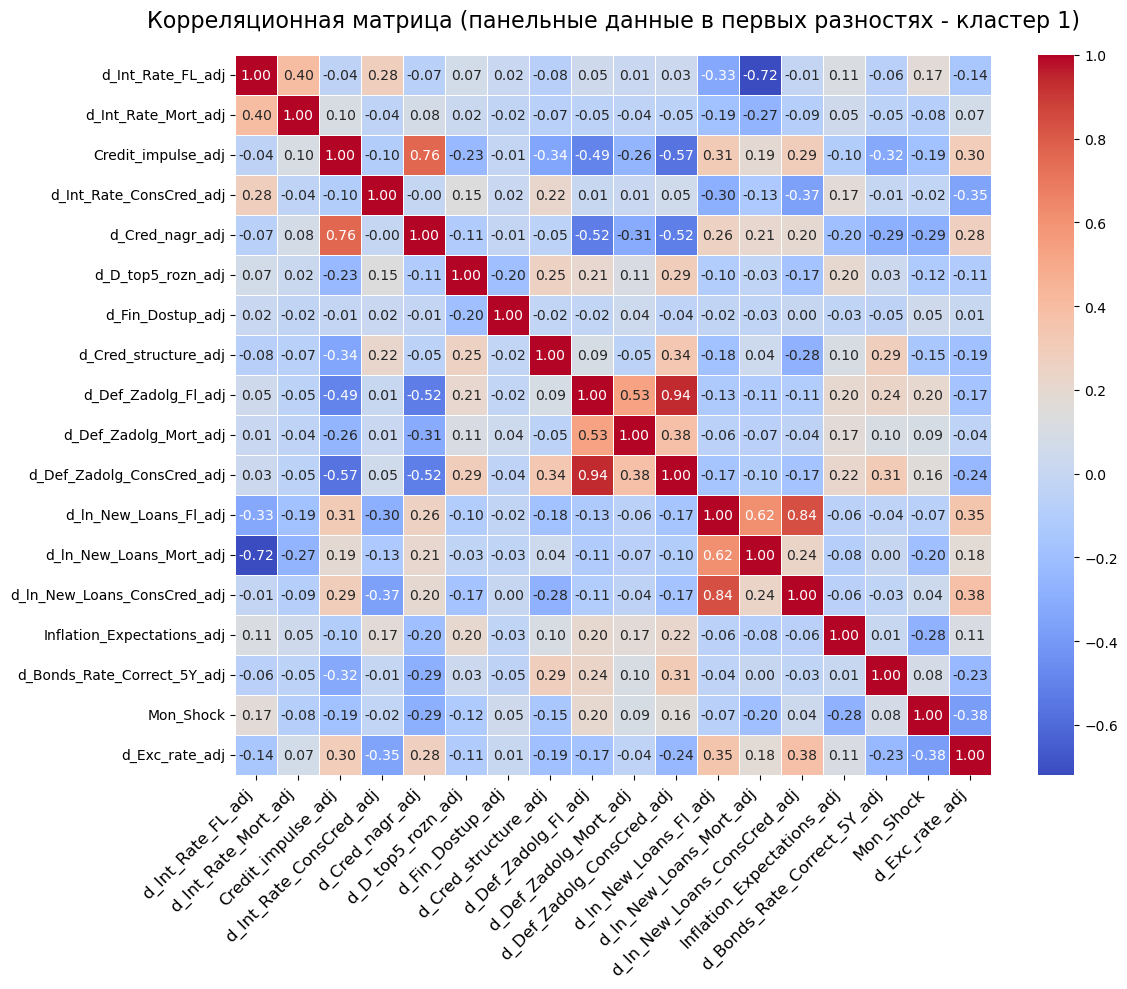

In [97]:
###############################
# КОРРЕЛЯЦИОННАЯ МАТРИЦА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - КЛАСТЕР 1
###############################
dd = descriptive_df.corr()
plt.figure(figsize=(12, 10))
fig = sns.heatmap(dd, annot=True,
                  fmt=".2f",
                  linewidth=0.5,
                  linecolor='white',
                  annot_kws={"size": 10},
                  cmap='coolwarm')

fig.set_title("Корреляционная матрица (панельные данные в первых разностях - кластер 1)",
             fontsize=16, pad=20)

fig.set_xticklabels(fig.get_xticklabels(),
                   rotation=45,
                   ha='right',
                   fontsize=12)

plt.tight_layout()

In [104]:
###############################
# Построение линейных моделей на панельных данных (кластер 1)
# (d_Int_Rate_Mort зависимая переменная)
###############################
print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 1)")
print("Зависимая переменная: d_Int_Rate_Mort_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
   # 'd_ln_New_Loans_Progr',
    'd_ln_New_Loans_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj'                        
]

dependent_var = 'd_Int_Rate_Mort_adj'


# Создаем копию df_reg для работы
df_clean = df_reg_clus_one.copy()  # Ð»Ð¾Ð³Ð¸ÐºÐ° Ð±ÐµÐ· Ð¸Ð·Ð¼ÐµÐ½ÐµÐ½Ð¸Ð¹

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
pooled_res, fe_res, re_res, pooled_success, fe_success, re_success = run_panel_regressions(
    y, X, cov_type='robust', cluster_entity=None
)


ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 1)
Зависимая переменная: d_Int_Rate_Mort_adj

МОДЕЛЬ 1: POOLED OLS
                           PooledOLS Estimation Summary                          
Dep. Variable:     d_Int_Rate_Mort_adj   R-squared:                        0.1980
Estimator:                   PooledOLS   R-squared (Between):              0.4039
No. Observations:                 2280   R-squared (Within):               0.1973
Date:                  Пн, дек 22 2025   R-squared (Overall):              0.1980
Time:                         17:53:03   Log-likelihood                   -2098.2
Cov. Estimator:                 Robust                                           
                                         F-statistic:                      46.658
Entities:                           30   P-value                           0.0000
Avg Obs:                        76.000   Distribution:                 F(12,2268)
Min Obs:                        76.000                              

In [ ]:
# Сохраняем результаты модели для экспорта
pooled_res_6 = pooled_res if pooled_success else None
fe_res_6 = fe_res if fe_success else None
re_res_6 = re_res if re_success else None


In [105]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)


run_spec_tests(
    y, X, pooled_res, fe_res, re_res, pooled_success, fe_success, re_success
)



ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: 0.2029
p-значение: 1.000000
df: 12

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 1149.0890
p-значение: 0.000000
N (регионов): 30, T (периодов): 76

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -9.7013
p-значение: 1.000000
df: (29, 2238)

Вывод: p >= 0.05 - Pooled адекватна


In [106]:
# Добавляем результаты в сводную таблицу
aggregator.add_model_results(
    re_res, 
    dependent_variable='d_Int_Rate_Mort_adj',
    subsample_name='Кластер_1',
    model_type='RE',
    specification_name='Модель_6'
)

In [107]:
###############################
# ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - КЛАСТЕР 2
###############################
descriptive_df = df_reg_clus_two[[  # Ð»Ð¾Ð³Ð¸ÐºÐ° Ð±ÐµÐ· Ð¸Ð·Ð¼ÐµÐ½ÐµÐ½Ð¸Ð¹
    'd_Int_Rate_FL_adj',
    'd_Int_Rate_Mort_adj',
    'Credit_impulse_adj',
    'd_Int_Rate_ConsCred_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'd_Def_Zadolg_Mort_adj',
    'd_Def_Zadolg_ConsCred_adj',
    'd_ln_New_Loans_Fl_adj',         
    'd_ln_New_Loans_Mort_adj',       
    'd_ln_New_Loans_ConsCred_adj',   
    'Inflation_Expectations_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'Mon_Shock',
    'd_Exc_rate_adj'
]]

desc = descriptive_df.describe().round(3).T

medians = descriptive_df.median()
desc['median'] = medians.round(3)

desc = desc.rename(columns={
    'mean': 'Среднее',
    'median': 'Медиана',
    'std': 'ст. откл.',
    'min': 'Мин.',
    'max': 'Макс.',
})

print("\n" + "="*60)
print("ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - КЛАСТЕР 2")
print("="*60)
print(desc[['Среднее', 'Медиана', 'ст. откл.', 'Мин.', 'Макс.']])


ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - КЛАСТЕР 2
                             Среднее  Медиана  ст. откл.    Мин.   Макс.
d_Int_Rate_FL_adj              0.069   -0.032      1.056  -2.825   5.474
d_Int_Rate_Mort_adj           -0.055   -0.076      0.637  -3.539   2.901
Credit_impulse_adj            -1.041   -0.242      7.272 -38.748  28.841
d_Int_Rate_ConsCred_adj        0.221    0.039      2.142 -12.313  20.565
d_Cred_nagr_adj               -0.001   -0.001      0.007  -0.019   0.018
d_D_top5_rozn_adj              0.000   -0.000      0.002  -0.004   0.008
d_Fin_Dostup_adj              -0.067   -0.034      0.483  -3.693   3.597
d_Cred_structure_adj           0.001    0.002      0.004  -0.013   0.019
d_Def_Zadolg_Fl_adj            0.002   -0.004      0.070  -0.212   0.244
d_Def_Zadolg_Mort_adj         -0.003   -0.004      0.022  -0.058   0.095
d_Def_Zadolg_ConsCred_adj      0.032    0.013      0.149  -0.329   0.747
d_ln_New_Loans_Fl_adj          0.004    0.016    

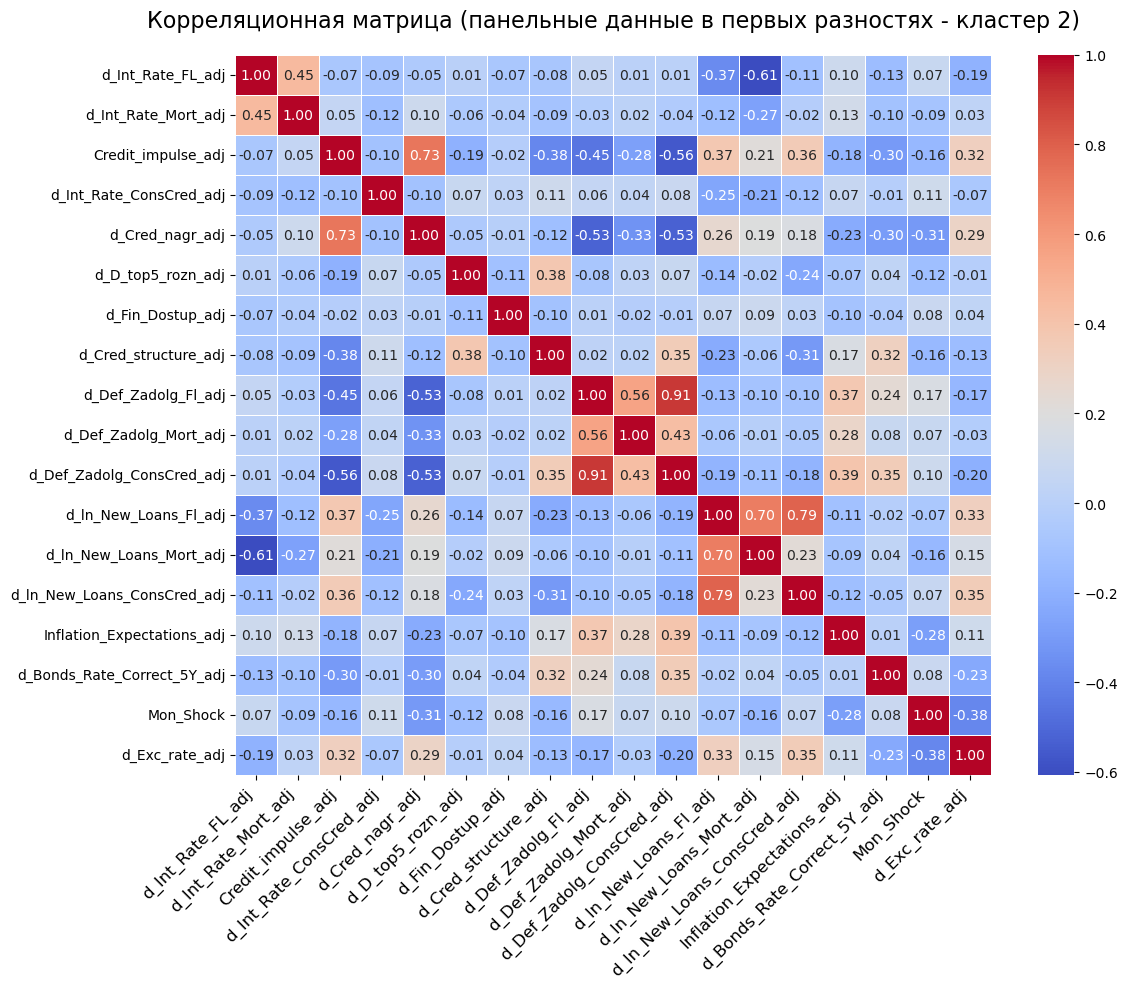

In [108]:
###############################
# КОРРЕЛЯЦИОННАЯ МАТРИЦА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - КЛАСТЕР 2
###############################
dd = descriptive_df.corr()
plt.figure(figsize=(12, 10))
fig = sns.heatmap(dd, annot=True,
                  fmt=".2f",
                  linewidth=0.5,
                  linecolor='white',
                  annot_kws={"size": 10},
                  cmap='coolwarm')

fig.set_title("Корреляционная матрица (панельные данные в первых разностях - кластер 2)",
             fontsize=16, pad=20)

fig.set_xticklabels(fig.get_xticklabels(),
                   rotation=45,
                   ha='right',
                   fontsize=12)

plt.tight_layout()

In [115]:
###############################
# Построение линейных моделей на панельных данных (кластер 2)
# (d_Int_Rate_Mort зависимая переменная)
###############################
print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 2)")
print("Зависимая переменная: d_Int_Rate_Mort_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
   # 'd_ln_New_Loans_Progr',
    'd_ln_New_Loans_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj'                        
]

dependent_var = 'd_Int_Rate_Mort_adj'


# Создаем копию df_reg для работы
df_clean = df_reg_clus_two.copy()  # Ð»Ð¾Ð³Ð¸ÐºÐ° Ð±ÐµÐ· Ð¸Ð·Ð¼ÐµÐ½ÐµÐ½Ð¸Ð¹

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
pooled_res, fe_res, re_res, pooled_success, fe_success, re_success = run_panel_regressions(
    y, X, cov_type='robust', cluster_entity=None
)


ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 2)
Зависимая переменная: d_Int_Rate_Mort_adj

МОДЕЛЬ 1: POOLED OLS
                           PooledOLS Estimation Summary                          
Dep. Variable:     d_Int_Rate_Mort_adj   R-squared:                        0.1673
Estimator:                   PooledOLS   R-squared (Between):              0.9300
No. Observations:                  228   R-squared (Within):               0.1609
Date:                  Пн, дек 22 2025   R-squared (Overall):              0.1673
Time:                         17:53:06   Log-likelihood                   -200.28
Cov. Estimator:                 Robust                                           
                                         F-statistic:                      3.6158
Entities:                            3   P-value                           0.0001
Avg Obs:                        76.000   Distribution:                  F(12,216)
Min Obs:                        76.000                              

In [ ]:
# Сохраняем результаты модели для экспорта
pooled_res_7 = pooled_res if pooled_success else None
fe_res_7 = fe_res if fe_success else None
re_res_7 = re_res if re_success else None


In [116]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)


run_spec_tests(
    y, X, pooled_res, fe_res, re_res, pooled_success, fe_success, re_success
)



ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: 3.5290
p-значение: 0.990518
df: 12

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 115.3599
p-значение: 0.000000
N (регионов): 3, T (периодов): 76

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -54.5631
p-значение: 1.000000
df: (2, 213)

Вывод: p >= 0.05 - Pooled адекватна


In [117]:
# Добавляем результаты в сводную таблицу
aggregator.add_model_results(
    re_res, 
    dependent_variable='d_Int_Rate_Mort_adj',
    subsample_name='Кластер_2',
    model_type='RE',
    specification_name='Модель_9'
)

In [118]:
###############################
# ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - КЛАСТЕР 3
###############################
descriptive_df = df_reg_clus_three[[  # Ð»Ð¾Ð³Ð¸ÐºÐ° Ð±ÐµÐ· Ð¸Ð·Ð¼ÐµÐ½ÐµÐ½Ð¸Ð¹
    'd_Int_Rate_FL_adj',
    'd_Int_Rate_Mort_adj',
    'Credit_impulse_adj',
    'd_Int_Rate_ConsCred_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'd_Def_Zadolg_Mort_adj',
    'd_Def_Zadolg_ConsCred_adj',
    'd_ln_New_Loans_Fl_adj',         
    'd_ln_New_Loans_Mort_adj',       
    'd_ln_New_Loans_ConsCred_adj',   
    'Inflation_Expectations_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'Mon_Shock',
    'd_Exc_rate_adj'
]]

desc = descriptive_df.describe().round(3).T

medians = descriptive_df.median()
desc['median'] = medians.round(3)

desc = desc.rename(columns={
    'mean': 'Среднее',
    'median': 'Медиана',
    'std': 'ст. откл.',
    'min': 'Мин.',
    'max': 'Макс.',
})

print("\n" + "="*60)
print("ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - КЛАСТЕР 2")
print("="*60)
print(desc[['Среднее', 'Медиана', 'ст. откл.', 'Мин.', 'Макс.']])


ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - КЛАСТЕР 2
                             Среднее  Медиана  ст. откл.    Мин.   Макс.
d_Int_Rate_FL_adj              0.077   -0.025      0.886  -2.040   5.028
d_Int_Rate_Mort_adj           -0.038   -0.073      0.502  -2.957   3.138
Credit_impulse_adj            -0.500   -0.114      5.279 -19.754  19.222
d_Int_Rate_ConsCred_adj        0.174    0.038      1.041  -3.936   7.515
d_Cred_nagr_adj               -0.001   -0.000      0.010  -0.034   0.027
d_D_top5_rozn_adj              0.002    0.001      0.003  -0.005   0.037
d_Fin_Dostup_adj              -0.073   -0.064      0.185  -1.337   0.871
d_Cred_structure_adj           0.002    0.002      0.003  -0.008   0.020
d_Def_Zadolg_Fl_adj           -0.005   -0.016      0.073  -0.297   0.461
d_Def_Zadolg_Mort_adj         -0.002   -0.004      0.027  -0.210   0.179
d_Def_Zadolg_ConsCred_adj      0.018   -0.020      0.144  -0.517   0.951
d_ln_New_Loans_Fl_adj          0.007    0.019    

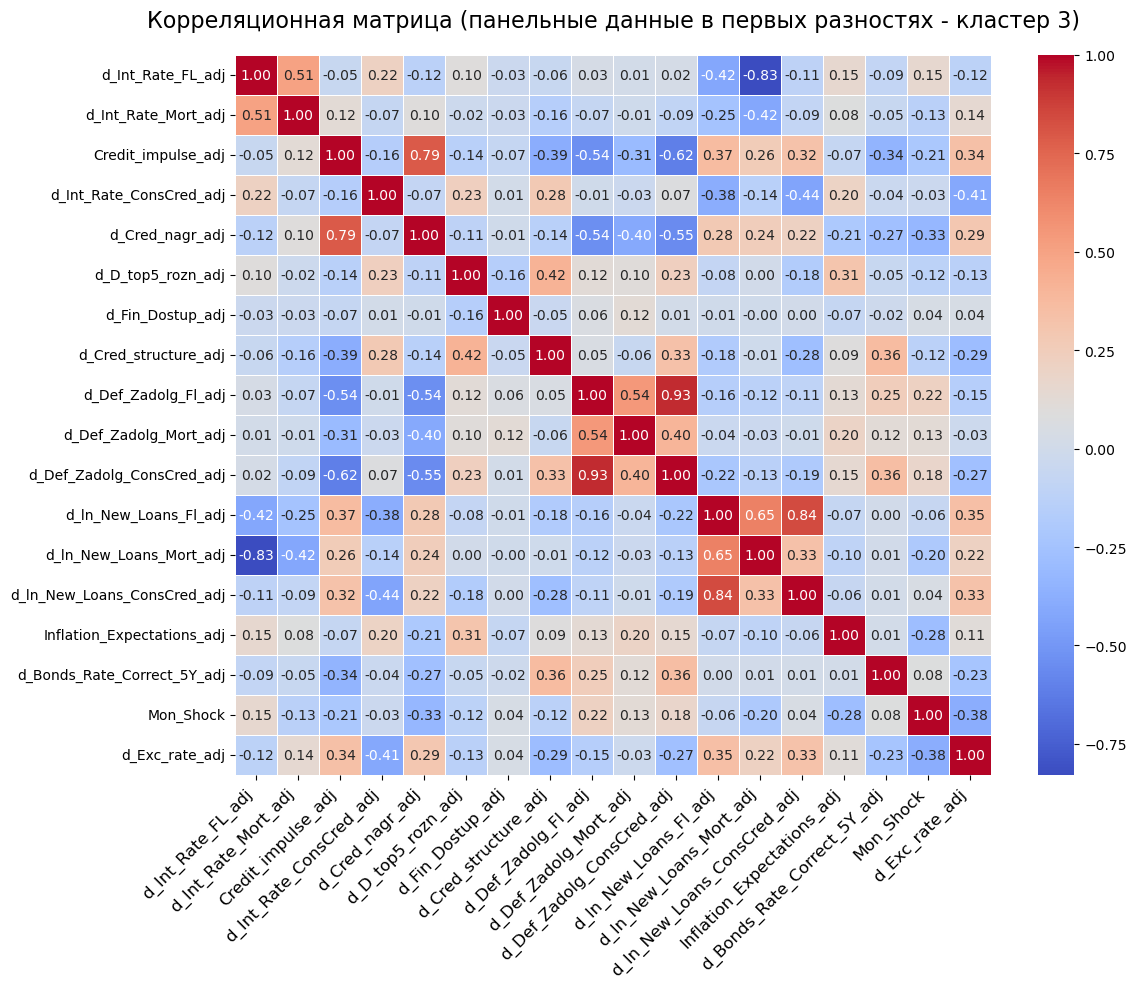

In [119]:
###############################
# КОРРЕЛЯЦИОННАЯ МАТРИЦА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - КЛАСТЕР 3
###############################
dd = descriptive_df.corr()
plt.figure(figsize=(12, 10))
fig = sns.heatmap(dd, annot=True,
                  fmt=".2f",
                  linewidth=0.5,
                  linecolor='white',
                  annot_kws={"size": 10},
                  cmap='coolwarm')

fig.set_title("Корреляционная матрица (панельные данные в первых разностях - кластер 3)",
             fontsize=16, pad=20)

fig.set_xticklabels(fig.get_xticklabels(),
                   rotation=45,
                   ha='right',
                   fontsize=12)

plt.tight_layout()

In [126]:
###############################
# Построение линейных моделей на панельных данных (кластер 3)
# (d_Int_Rate_Mort зависимая переменная)
###############################
print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 3)")
print("Зависимая переменная: d_Int_Rate_Mort_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
   # 'd_ln_New_Loans_Progr',
    'd_ln_New_Loans_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj'                        
]

dependent_var = 'd_Int_Rate_Mort_adj'


# Создаем копию df_reg для работы
df_clean = df_reg_clus_three.copy()  # Ð»Ð¾Ð³Ð¸ÐºÐ° Ð±ÐµÐ· Ð¸Ð·Ð¼ÐµÐ½ÐµÐ½Ð¸Ð¹

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
pooled_res, fe_res, re_res, pooled_success, fe_success, re_success = run_panel_regressions(
    y, X, cov_type='robust', cluster_entity=None
)


ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 3)
Зависимая переменная: d_Int_Rate_Mort_adj

МОДЕЛЬ 1: POOLED OLS
                           PooledOLS Estimation Summary                          
Dep. Variable:     d_Int_Rate_Mort_adj   R-squared:                        0.3252
Estimator:                   PooledOLS   R-squared (Between):              0.9899
No. Observations:                  532   R-squared (Within):               0.3215
Date:                  Пн, дек 22 2025   R-squared (Overall):              0.3252
Time:                         17:56:05   Log-likelihood                   -285.04
Cov. Estimator:                 Robust                                           
                                         F-statistic:                      20.886
Entities:                            7   P-value                           0.0000
Avg Obs:                        76.000   Distribution:                  F(12,520)
Min Obs:                        76.000                              

In [ ]:
# Сохраняем результаты модели для экспорта
pooled_res_8 = pooled_res if pooled_success else None
fe_res_8 = fe_res if fe_success else None
re_res_8 = re_res if re_success else None


In [127]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)


run_spec_tests(
    y, X, pooled_res, fe_res, re_res, pooled_success, fe_success, re_success
)



ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: 0.0078
p-значение: 1.000000
df: 12

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 269.5011
p-значение: 0.000000
N (регионов): 7, T (периодов): 76

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -0.2847
p-значение: 1.000000
df: (6, 513)

Вывод: p >= 0.05 - Pooled адекватна


In [128]:
# Добавляем результаты в сводную таблицу
aggregator.add_model_results(
    re_res, 
    dependent_variable='d_Int_Rate_Mort_adj',
    subsample_name='Кластер_3',
    model_type='RE',
    specification_name='Модель_12'
)

In [129]:
full_table = aggregator.build_table(
    include_pvalues=True,
    decimals=3
)
print(full_table)

                                        Модель_1                 Модель_2  \
Зависимая переменная           d_Int_Rate_FL_adj  d_Int_Rate_ConsCred_adj   
d_Int_Rate_FL_lag1_adj            -0.107 (0.104)                            
d_Cred_nagr_adj                    1.932 (0.641)         10.583** (0.041)   
d_D_top5_rozn_adj              31.608*** (0.007)        28.149*** (0.005)   
d_Fin_Dostup_adj                   0.019 (0.767)         0.224*** (0.001)   
Credit_impulse_adj                 0.007 (0.215)           -0.006 (0.490)   
d_Cred_structure_adj          -42.140*** (0.000)        37.559*** (0.000)   
d_Def_Zadolg_Fl_adj               -0.084 (0.763)                            
Mon_Shock                       2.938*** (0.000)           -0.297 (0.670)   
d_ln_New_Loans_Fl_adj          -2.948*** (0.000)                            
d_Bonds_Rate_Correct_5Y_adj       -0.223 (0.172)        -0.561*** (0.001)   
Inflation_Expectations_adj      0.017*** (0.000)         0.019*** (0.000)   

In [130]:
#full_table.to_excel('results_panel.xlsx')

In [55]:
###########################################
 #ПОСТРОЕНИЕ МОДЕЛЕЙ С ROISFIX
###########################################
# df_exog = pd.read_excel('exog.xlsx')

In [56]:
df_roisfix.head()

,Date,d_ln_ROISFIX
0,2019-03-01,-0.005307
1,2019-04-01,0.002428
2,2019-05-01,0.000728
3,2019-06-01,-0.014620
4,2019-07-01,-0.024679


In [57]:
df_reg.head()  # Ð»Ð¾Ð³Ð¸ÐºÐ° Ð±ÐµÐ· Ð¸Ð·Ð¼ÐµÐ½ÐµÐ½Ð¸Ð¹

,Region,Date,d_Int_Rate_FL_adj,d_Int_Rate_FL_lag1_adj,d_Int_Rate_Mort_adj,Credit_impulse_adj,d_Int_Rate_Mort_lag1_adj,d_Int_Rate_ConsCred_adj,d_Int_Rate_ConsCred_lag1_adj,d_Cred_nagr_adj,...,d_Def_Zadolg_ConsCred_adj,d_ln_New_Loans_Fl_adj,d_ln_New_Loans_Mort_adj,d_ln_New_Loans_ConsCred_adj,Inflation_Expectations_adj,d_Bonds_Rate_Correct_5Y_adj,Mon_Shock,d_Exc_rate_adj,Cluster_1,Cluster_2
0,Алтайский край,2019-05-01,0.002751,0.332021,0.222952,2.896283,0.534088,-0.009904,0.094145,0.001391,...,-0.188653,0.076853,0.087517,0.035261,9.556202,-0.118900,-0.003213,2.202704,1,0
1,Алтайский край,2019-06-01,-0.135162,0.028915,-0.013543,3.008792,0.175740,-0.029205,0.005160,0.000063,...,-0.163713,0.037104,0.018172,-0.052758,9.236921,-0.018078,-0.015468,1.590251,1,0
2,Алтайский край,2019-07-01,-0.011789,-0.142436,0.120897,2.623327,-0.231480,-0.062038,-0.020563,0.001691,...,-0.188312,-0.101967,-0.014579,-0.078541,9.331369,-0.023652,-0.000333,-1.536596,1,0
3,Алтайский край,2019-08-01,0.303013,-0.030554,-0.241133,3.494039,-0.121719,0.220345,-0.071617,0.001204,...,-0.071152,0.027416,-0.053992,0.056817,9.330758,0.002706,0.005457,0.875305,1,0
4,Алтайский край,2019-09-01,-0.173113,0.204788,-0.288290,3.024105,-0.058210,-0.052563,0.227203,0.001501,...,-0.214003,-0.016606,0.047768,-0.009646,9.170678,0.049196,0.013868,-0.651120,1,0


In [58]:
# df_exog = df_exog.merge(
#     df_roisfix,
#     on='Date',         
#     how='left'         
# )


In [59]:
df_reg.info()  # Ð»Ð¾Ð³Ð¸ÐºÐ° Ð±ÐµÐ· Ð¸Ð·Ð¼ÐµÐ½ÐµÐ½Ð¸Ð¹

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3040 entries, 0 to 3039
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Region                        3040 non-null   object        
 1   Date                          3040 non-null   datetime64[ns]
 2   d_Int_Rate_FL_adj             3040 non-null   float64       
 3   d_Int_Rate_FL_lag1_adj        3040 non-null   float64       
 4   d_Int_Rate_Mort_adj           3040 non-null   float64       
 5   Credit_impulse_adj            3040 non-null   float64       
 6   d_Int_Rate_Mort_lag1_adj      3040 non-null   float64       
 7   d_Int_Rate_ConsCred_adj       3040 non-null   float64       
 8   d_Int_Rate_ConsCred_lag1_adj  3040 non-null   float64       
 9   d_Cred_nagr_adj               3040 non-null   float64       
 10  d_D_top5_rozn_adj             3040 non-null   float64       
 11  d_Fin_Dostup_adj              

In [60]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 1 спецификация (ROISFIX)
###############################

vif_variables = [
    'd_Int_Rate_FL_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
   # 'd_ln_New_Loans_Progr',
    'd_ln_ROISFIX',
    'd_ln_New_Loans_Fl_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj'                   
]

df_vif = df_reg[vif_variables].copy()  # Ð»Ð¾Ð³Ð¸ÐºÐ° Ð±ÐµÐ· Ð¸Ð·Ð¼ÐµÐ½ÐµÐ½Ð¸Ð¹
df_vif = df_vif.dropna()
X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 1 (ROISFIX)")
print("="*60) 
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 1 (ROISFIX)
                   Variable      VIF
               d_ln_ROISFIX 3.671867
            d_Cred_nagr_adj 3.368960
         Credit_impulse_adj 3.201396
             d_Exc_rate_adj 2.385301
 Inflation_Expectations_adj 2.026036
        d_Def_Zadolg_Fl_adj 1.537617
       d_Cred_structure_adj 1.501195
d_Bonds_Rate_Correct_5Y_adj 1.353111
      d_ln_New_Loans_Fl_adj 1.301104
          d_D_top5_rozn_adj 1.225218
     d_Int_Rate_FL_lag1_adj 1.114957
           d_Fin_Dostup_adj 1.039579


In [61]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 2 спецификация (ROISFIX)
###############################

vif_variables = [
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_ConsCred_adj',
   # 'd_ln_New_Loans_Progr',
    'd_ln_ROISFIX',
    'd_ln_New_Loans_ConsCred_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj'                   
]

df_vif = df_reg[vif_variables].copy()  # Ð»Ð¾Ð³Ð¸ÐºÐ° Ð±ÐµÐ· Ð¸Ð·Ð¼ÐµÐ½ÐµÐ½Ð¸Ð¹
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 2 (ROISFIX)")
print("="*60)
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 2 (ROISFIX)
                    Variable      VIF
                d_ln_ROISFIX 3.647655
             d_Cred_nagr_adj 3.348261
          Credit_impulse_adj 3.215639
              d_Exc_rate_adj 2.507511
  Inflation_Expectations_adj 1.985637
   d_Def_Zadolg_ConsCred_adj 1.758628
        d_Cred_structure_adj 1.549090
 d_ln_New_Loans_ConsCred_adj 1.372839
 d_Bonds_Rate_Correct_5Y_adj 1.330099
           d_D_top5_rozn_adj 1.230726
d_Int_Rate_ConsCred_lag1_adj 1.078630
            d_Fin_Dostup_adj 1.039755


In [62]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 3 спецификация (ROISFIX)
###############################

vif_variables = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
    #'d_ln_New_Loans_Progr',
    'd_ln_New_Loans_Mort_adj',
    'd_ln_ROISFIX',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj'                     
]

df_vif = df_reg[vif_variables].copy()  # Ð»Ð¾Ð³Ð¸ÐºÐ° Ð±ÐµÐ· Ð¸Ð·Ð¼ÐµÐ½ÐµÐ½Ð¸Ð¹
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 3 (ROISFIX)")
print("="*60)
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 3 (ROISFIX)
                   Variable      VIF
               d_ln_ROISFIX 3.387480
            d_Cred_nagr_adj 3.318107
         Credit_impulse_adj 3.096494
             d_Exc_rate_adj 2.131450
 Inflation_Expectations_adj 1.938486
       d_Cred_structure_adj 1.510130
d_Bonds_Rate_Correct_5Y_adj 1.319531
          d_D_top5_rozn_adj 1.218535
      d_Def_Zadolg_Mort_adj 1.162935
    d_ln_New_Loans_Mort_adj 1.097798
           d_Fin_Dostup_adj 1.042224
   d_Int_Rate_Mort_lag1_adj 1.041451


In [63]:
###############################
# ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - ОБЩАЯ ВЫБОРКА (ROISFIX)
###############################
descriptive_df = df_reg[[  # Ð»Ð¾Ð³Ð¸ÐºÐ° Ð±ÐµÐ· Ð¸Ð·Ð¼ÐµÐ½ÐµÐ½Ð¸Ð¹
    'd_Int_Rate_FL_adj',
    'd_Int_Rate_Mort_adj',
    'Credit_impulse_adj',
    'd_Int_Rate_ConsCred_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'd_Def_Zadolg_Mort_adj',
    'd_Def_Zadolg_ConsCred_adj',
    'd_ln_New_Loans_Fl_adj',         
    'd_ln_New_Loans_Mort_adj',       
    'd_ln_New_Loans_ConsCred_adj',   
    'Inflation_Expectations_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_ln_ROISFIX',
    'd_Exc_rate_adj',
    'Cluster_1',
    'Cluster_2'
]]

desc = descriptive_df.describe().round(3).T

medians = descriptive_df.median()
desc['median'] = medians.round(3)

desc = desc.rename(columns={
    'mean': 'Среднее',
    'median': 'Медиана',
    'std': 'ст. откл.',
    'min': 'Мин.',
    'max': 'Макс.',
})

print("\n" + "="*60)
print("ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - ОБЩАЯ ВЫБОРКА (ROISFIX)")
print("="*60)
print(desc[['Среднее', 'Медиана', 'ст. откл.', 'Мин.', 'Макс.']])


ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - ОБЩАЯ ВЫБОРКА (ROISFIX)
                             Среднее  Медиана  ст. откл.    Мин.   Макс.
d_Int_Rate_FL_adj              0.078   -0.035      1.038 -13.724  13.319
d_Int_Rate_Mort_adj           -0.036   -0.053      0.647  -4.479   5.582
Credit_impulse_adj            -0.638   -0.061      6.961 -55.926  56.097
d_Int_Rate_ConsCred_adj        0.184    0.035      1.340 -16.410  21.073
d_Cred_nagr_adj               -0.001    0.000      0.010  -0.059   0.037
d_D_top5_rozn_adj              0.001    0.001      0.003  -0.024   0.037
d_Fin_Dostup_adj              -0.049   -0.030      0.273  -5.750   3.597
d_Cred_structure_adj           0.001    0.001      0.003  -0.022   0.021
d_Def_Zadolg_Fl_adj            0.003   -0.010      0.093  -0.834   1.286
d_Def_Zadolg_Mort_adj         -0.000   -0.004      0.041  -0.584   0.544
d_Def_Zadolg_ConsCred_adj      0.028    0.001      0.168  -1.049   2.716
d_ln_New_Loans_Fl_adj          0.00

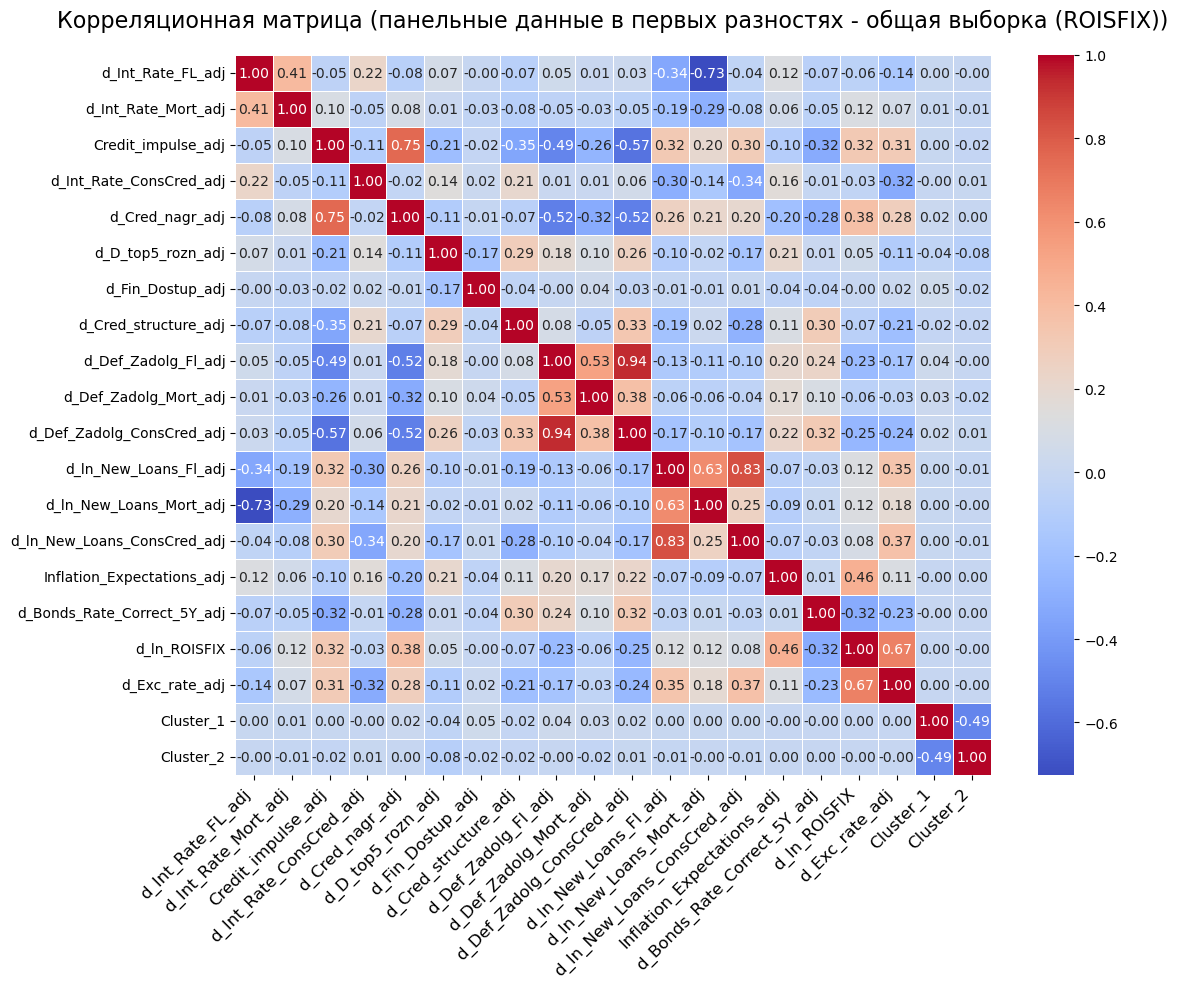

In [64]:
###############################
# КОРРЕЛЯЦИОННАЯ МАТРИЦА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - ОБЩАЯ ВЫБОРКА (ROISFIX)
###############################
dd = descriptive_df.corr()
plt.figure(figsize=(12, 10))
fig = sns.heatmap(dd, annot=True,
                  fmt=".2f",
                  linewidth=0.5,
                  linecolor='white',
                  annot_kws={"size": 10},
                  cmap='coolwarm')

fig.set_title("Корреляционная матрица (панельные данные в первых разностях - общая выборка (ROISFIX))",
             fontsize=16, pad=20)

fig.set_xticklabels(fig.get_xticklabels(),
                   rotation=45,
                   ha='right',
                   fontsize=12)

plt.tight_layout()

In [72]:
###############################
# Построение линейных моделей на панельных данных (общая выборка) ROISFIX
# (d_Int_Rate_Mort зависимая переменная)
###############################

print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА ROISFIX)")
print("Зависимая переменная: d_Int_Rate_Mort_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
   # 'd_ln_New_Loans_Progr',
    'd_ln_New_Loans_Mort_adj',
    'd_ln_ROISFIX',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj'                        
]

dependent_var = 'd_Int_Rate_Mort_adj'


# Создаем копию df_reg для работы
df_clean = df_reg.copy()  # Ð»Ð¾Ð³Ð¸ÐºÐ° Ð±ÐµÐ· Ð¸Ð·Ð¼ÐµÐ½ÐµÐ½Ð¸Ð¹

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
pooled_res, fe_res, re_res, pooled_success, fe_success, re_success = run_panel_regressions(
    y, X, cov_type='clustered', cluster_entity=True
)


ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)
Зависимая переменная: d_Int_Rate_Mort_adj
ERROR - d_Int_Rate_Mort_adj отсутствует в df_reg_temp

МОДЕЛЬ 1: POOLED OLS
                           PooledOLS Estimation Summary                          
Dep. Variable:     d_Int_Rate_Mort_adj   R-squared:                        0.1999
Estimator:                   PooledOLS   R-squared (Between):              0.5523
No. Observations:                 3040   R-squared (Within):               0.1984
Date:                  Вт, дек 23 2025   R-squared (Overall):              0.1999
Time:                         12:02:23   Log-likelihood                   -2655.4
Cov. Estimator:              Clustered                                           
                                         F-statistic:                      63.034
Entities:                           40   P-value                           0.0000
Avg Obs:                        76.000   Distribution:                 F(12,3028)
Min Obs:  

In [ ]:
# Сохраняем результаты модели для экспорта
pooled_res_9 = pooled_res if pooled_success else None
fe_res_9 = fe_res if fe_success else None
re_res_9 = re_res if re_success else None


In [73]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)


run_spec_tests(
    y, X, pooled_res, fe_res, re_res, pooled_success, fe_success, re_success
)



ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: 27.2314
p-значение: 0.007156
df: 12

Вывод: p < 0.05 - Используйте FIXED EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 1533.1696
p-значение: 0.000000
N (регионов): 40, T (периодов): 76

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -9.3061
p-значение: 1.000000
df: (39, 2988)

Вывод: p >= 0.05 - Pooled адекватна


In [74]:
# Добавляем результаты в сводную таблицу
aggregator_roisfix.add_model_results(
    fe_res, 
    dependent_variable='d_Int_Rate_Mort_adj',
    subsample_name='Общая выборка',
    model_type='FE',
    specification_name='Модель_15'
)

In [77]:
df_exog_clus_one = df_exog[df_exog['Cluster_1'] == 1].copy()

In [78]:
df_exog_clus_two = df_exog[df_exog['Cluster_2'] == 1].copy()

In [80]:
df_exog_clus_three = df_exog[(df_exog['Cluster_1'] == 0) & (df_exog['Cluster_2'] == 0)].copy()

In [99]:
###############################
# Построение линейных моделей на панельных данных (кластер 1 ROISFIX)
# (d_Int_Rate_Mort зависимая переменная)
###############################
print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 1 ROISFIX)")
print("Зависимая переменная: d_Int_Rate_Mort_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
   # 'd_ln_New_Loans_Progr',
    'd_ln_New_Loans_Mort_adj',
    'd_ln_ROISFIX',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj'                        
]

dependent_var = 'd_Int_Rate_Mort_adj'


# Создаем копию df_reg для работы
df_clean = df_reg_clus_one.copy()  # Ð»Ð¾Ð³Ð¸ÐºÐ° Ð±ÐµÐ· Ð¸Ð·Ð¼ÐµÐ½ÐµÐ½Ð¸Ð¹

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
pooled_res, fe_res, re_res, pooled_success, fe_success, re_success = run_panel_regressions(
    y, X, cov_type='robust', cluster_entity=None
)


ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 1 ROISFIX)
Зависимая переменная: d_Int_Rate_Mort_adj
ERROR - d_Int_Rate_Mort_adj отсутствует в df_reg_temp

МОДЕЛЬ 1: POOLED OLS
                           PooledOLS Estimation Summary                          
Dep. Variable:     d_Int_Rate_Mort_adj   R-squared:                        0.1977
Estimator:                   PooledOLS   R-squared (Between):              0.4198
No. Observations:                 2280   R-squared (Within):               0.1969
Date:                  Вт, дек 23 2025   R-squared (Overall):              0.1977
Time:                         12:23:10   Log-likelihood                   -2098.6
Cov. Estimator:                 Robust                                           
                                         F-statistic:                      46.572
Entities:                           30   P-value                           0.0000
Avg Obs:                        76.000   Distribution:                 F(12,2268)
Min Ob

In [ ]:
# Сохраняем результаты модели для экспорта
pooled_res_10 = pooled_res if pooled_success else None
fe_res_10 = fe_res if fe_success else None
re_res_10 = re_res if re_success else None


In [100]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)


run_spec_tests(
    y, X, pooled_res, fe_res, re_res, pooled_success, fe_success, re_success
)



ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: 0.0534
p-значение: 1.000000
df: 12

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 1149.2534
p-значение: 0.000000
N (регионов): 30, T (периодов): 76

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -6.0533
p-значение: 1.000000
df: (29, 2238)

Вывод: p >= 0.05 - Pooled адекватна


In [101]:
# Добавляем результаты в сводную таблицу
aggregator_roisfix.add_model_results(
    re_res, 
    dependent_variable='d_Int_Rate_Mort_adj',
    subsample_name='Кластер_1',
    model_type='RE',
    specification_name='Модель_18'
)

In [112]:
###############################
# Построение линейных моделей на панельных данных (кластер 2 ROISFIX)
# (d_Int_Rate_Mort зависимая переменная)
###############################
print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 2 ROISFIX)")
print("Зависимая переменная: d_Int_Rate_Mort_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
   # 'd_ln_New_Loans_Progr',
    'd_ln_New_Loans_Mort_adj',
    'd_ln_ROISFIX',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj'                        
]

dependent_var = 'd_Int_Rate_Mort_adj'


# Создаем копию df_reg для работы
df_clean = df_reg_clus_two.copy()  # Ð»Ð¾Ð³Ð¸ÐºÐ° Ð±ÐµÐ· Ð¸Ð·Ð¼ÐµÐ½ÐµÐ½Ð¸Ð¹

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
pooled_res, fe_res, re_res, pooled_success, fe_success, re_success = run_panel_regressions(
    y, X, cov_type='robust', cluster_entity=None
)


ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 2 ROISFIX)
Зависимая переменная: d_Int_Rate_Mort_adj
ERROR - d_Int_Rate_Mort_adj отсутствует в df_reg_temp

МОДЕЛЬ 1: POOLED OLS
                           PooledOLS Estimation Summary                          
Dep. Variable:     d_Int_Rate_Mort_adj   R-squared:                        0.1641
Estimator:                   PooledOLS   R-squared (Between):              0.9621
No. Observations:                  228   R-squared (Within):               0.1575
Date:                  Вт, дек 23 2025   R-squared (Overall):              0.1641
Time:                         12:29:48   Log-likelihood                   -200.71
Cov. Estimator:                 Robust                                           
                                         F-statistic:                      3.5348
Entities:                            3   P-value                           0.0001
Avg Obs:                        76.000   Distribution:                  F(12,216)
Min Ob

In [ ]:
# Сохраняем результаты модели для экспорта
pooled_res_11 = pooled_res if pooled_success else None
fe_res_11 = fe_res if fe_success else None
re_res_11 = re_res if re_success else None


In [113]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)


run_spec_tests(
    y, X, pooled_res, fe_res, re_res, pooled_success, fe_success, re_success
)



ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: 0.7445
p-значение: 0.999997
df: 12

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 115.4337
p-значение: 0.000000
N (регионов): 3, T (периодов): 76

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -61.8132
p-значение: 1.000000
df: (2, 213)

Вывод: p >= 0.05 - Pooled адекватна


In [114]:
# Добавляем результаты в сводную таблицу
aggregator_roisfix.add_model_results(
    re_res, 
    dependent_variable='d_Int_Rate_Mort_adj',
    subsample_name='Кластер_2',
    model_type='RE',
    specification_name='Модель_21'
)

In [125]:
###############################
# Построение линейных моделей на панельных данных (кластер 3 ROISFIX)
# (d_Int_Rate_Mort зависимая переменная)
###############################
print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 3 ROISFIX)")
print("Зависимая переменная: d_Int_Rate_Mort_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
   # 'd_ln_New_Loans_Progr',
    'd_ln_New_Loans_Mort_adj',
    'd_ln_ROISFIX',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj'                        
]

dependent_var = 'd_Int_Rate_Mort_adj'


# Создаем копию df_reg для работы
df_clean = df_reg_clus_three.copy()  # Ð»Ð¾Ð³Ð¸ÐºÐ° Ð±ÐµÐ· Ð¸Ð·Ð¼ÐµÐ½ÐµÐ½Ð¸Ð¹

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
pooled_res, fe_res, re_res, pooled_success, fe_success, re_success = run_panel_regressions(
    y, X, cov_type='robust', cluster_entity=None
)


ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 3 ROISFIX)
Зависимая переменная: d_Int_Rate_Mort_adj
ERROR - d_Int_Rate_Mort_adj отсутствует в df_reg_temp

МОДЕЛЬ 1: POOLED OLS
                           PooledOLS Estimation Summary                          
Dep. Variable:     d_Int_Rate_Mort_adj   R-squared:                        0.3093
Estimator:                   PooledOLS   R-squared (Between):              0.9879
No. Observations:                  532   R-squared (Within):               0.3055
Date:                  Вт, дек 23 2025   R-squared (Overall):              0.3093
Time:                         12:35:32   Log-likelihood                   -291.25
Cov. Estimator:                 Robust                                           
                                         F-statistic:                      19.405
Entities:                            7   P-value                           0.0000
Avg Obs:                        76.000   Distribution:                  F(12,520)
Min Ob

In [ ]:
# Сохраняем результаты модели для экспорта
pooled_res_12 = pooled_res if pooled_success else None
fe_res_12 = fe_res if fe_success else None
re_res_12 = re_res if re_success else None


In [126]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)


run_spec_tests(
    y, X, pooled_res, fe_res, re_res, pooled_success, fe_success, re_success
)



ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: 0.0666
p-значение: 1.000000
df: 12

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 269.4937
p-значение: 0.000000
N (регионов): 7, T (периодов): 76

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -1.1878
p-значение: 1.000000
df: (6, 513)

Вывод: p >= 0.05 - Pooled адекватна


In [127]:
# Добавляем результаты в сводную таблицу
aggregator_roisfix.add_model_results(
    re_res, 
    dependent_variable='d_Int_Rate_Mort_adj',
    subsample_name='Кластер_3',
    model_type='RE',
    specification_name='Модель_24'
)

In [128]:
full_table = aggregator_roisfix.build_table(
    include_pvalues=True,
    decimals=3
)
print(full_table)

                                       Модель_13                Модель_14  \
Зависимая переменная           d_Int_Rate_FL_adj  d_Int_Rate_ConsCred_adj   
d_Int_Rate_FL_lag1_adj            -0.088 (0.182)                            
d_Cred_nagr_adj                   -0.112 (0.979)            4.983 (0.337)   
d_D_top5_rozn_adj               27.753** (0.023)          19.571* (0.057)   
d_Fin_Dostup_adj                   0.035 (0.582)         0.212*** (0.001)   
Credit_impulse_adj                 0.007 (0.209)           -0.007 (0.448)   
d_Cred_structure_adj          -49.710*** (0.000)        37.105*** (0.000)   
d_Def_Zadolg_Fl_adj                0.071 (0.795)                            
d_ln_ROISFIX                   -0.735*** (0.000)         2.555*** (0.000)   
d_ln_New_Loans_Fl_adj          -2.965*** (0.000)                            
d_Bonds_Rate_Correct_5Y_adj       -0.274 (0.109)         -0.412** (0.015)   
Inflation_Expectations_adj      0.016*** (0.000)         0.017*** (0.000)   

In [117]:
full_table_Int_FL.to_excel('results_panel_Int_FL.xlsx')
full_table_Int_ConsCred.to_excel('results_panel_Int_ConsCred.xlsx')
full_table_Int_Mort.to_excel('results_panel_Int_Mort.xlsx')

In [ ]:
'''df_clean.head()

###############################
# Построение PVAR S-GMM моделей
###############################
from pydynpd import regression

# Подготовка данных
df_for_gmm = df_clean.reset_index()
df_for_gmm = df_for_gmm.sort_values(['Region', 'Date'])

# System GMM 

# Используем спецификацию, которая работала ранее
command_str_system = (
    'd_Int_Rate_FL_adj L1.d_Int_Rate_FL_adj '
    'd_Cred_nagr_adj d_D_top5_rozn_adj '
    'Mon_Shock d_Bonds_Rate_Correct_5Y_adj d_Exc_rate_adj | '
    'gmm(d_Int_Rate_FL_adj, 2:4) '
    'iv(d_Cred_nagr_adj d_D_top5_rozn_adj Mon_Shock d_Bonds_Rate_Correct_5Y_adj d_Exc_rate_adj) | '
    'collapse'
)

mydpd_system = regression.abond(command_str_system, df_for_gmm, ['Region', 'Date'])'''


In [ ]:
from model_results_export import ModelResultsAggregator, ensure_results_dir, add_model_set, build_and_export
import os

dep_var_name = 'd_Int_Rate_Mort_adj'
base_name = dep_var_name
if base_name.startswith('d_'):
    base_name = base_name[2:]
if base_name.endswith('_adj'):
    base_name = base_name[:-4]

results_dir = ensure_results_dir('Results')

model_specs_all = [
    {
        'spec_name': 'Модель_1',
        'dependent_var': dep_var_name,
        'subsample': 'Общая выборка',
        'results': {
            'pooled': pooled_res_1,
            'fe': fe_res_1,
            're': re_res_1
        }
    },
    {
        'spec_name': 'Модель_2',
        'dependent_var': dep_var_name,
        'subsample': 'Общая выборка',
        'results': {
            'pooled': pooled_res_2,
            'fe': fe_res_2,
            're': re_res_2
        }
    },
    {
        'spec_name': 'Модель_3',
        'dependent_var': dep_var_name,
        'subsample': 'Общая выборка',
        'results': {
            'pooled': pooled_res_3,
            'fe': fe_res_3,
            're': re_res_3
        }
    },
    {
        'spec_name': 'Модель_4',
        'dependent_var': dep_var_name,
        'subsample': 'Общая выборка',
        'results': {
            'pooled': pooled_res_4,
            'fe': fe_res_4,
            're': re_res_4
        }
    },
    {
        'spec_name': 'Модель_5',
        'dependent_var': dep_var_name,
        'subsample': 'Общая выборка',
        'results': {
            'pooled': pooled_res_5,
            'fe': fe_res_5,
            're': re_res_5
        }
    },
    {
        'spec_name': 'Модель_6',
        'dependent_var': dep_var_name,
        'subsample': 'Общая выборка',
        'results': {
            'pooled': pooled_res_9,
            'fe': fe_res_9,
            're': re_res_9
        }
    }
]

model_specs_cluster = [
    {
        'spec_name': 'Модель_1',
        'dependent_var': dep_var_name,
        'subsample': 'Кластер 1',
        'results': {
            'pooled': pooled_res_6,
            'fe': fe_res_6,
            're': re_res_6
        }
    },
    {
        'spec_name': 'Модель_2',
        'dependent_var': dep_var_name,
        'subsample': 'Кластер 1',
        'results': {
            'pooled': pooled_res_10,
            'fe': fe_res_10,
            're': re_res_10
        }
    },
    {
        'spec_name': 'Модель_3',
        'dependent_var': dep_var_name,
        'subsample': 'Кластер 2',
        'results': {
            'pooled': pooled_res_7,
            'fe': fe_res_7,
            're': re_res_7
        }
    },
    {
        'spec_name': 'Модель_4',
        'dependent_var': dep_var_name,
        'subsample': 'Кластер 2',
        'results': {
            'pooled': pooled_res_11,
            'fe': fe_res_11,
            're': re_res_11
        }
    },
    {
        'spec_name': 'Модель_5',
        'dependent_var': dep_var_name,
        'subsample': 'Кластер 3',
        'results': {
            'pooled': pooled_res_8,
            'fe': fe_res_8,
            're': re_res_8
        }
    },
    {
        'spec_name': 'Модель_6',
        'dependent_var': dep_var_name,
        'subsample': 'Кластер 3',
        'results': {
            'pooled': pooled_res_12,
            'fe': fe_res_12,
            're': re_res_12
        }
    }
]

aggregator_all = ModelResultsAggregator()
for spec in model_specs_all:
    add_model_set(aggregator_all, spec)

out_all = os.path.join(results_dir, f"{base_name}_all_data.xlsx")
build_and_export(aggregator_all, out_all, include_pvalues=True, decimals=3)

aggregator_cluster = ModelResultsAggregator()
for spec in model_specs_cluster:
    add_model_set(aggregator_cluster, spec)

out_cluster = os.path.join(results_dir, f"{base_name}_cluster_data.xlsx")
build_and_export(aggregator_cluster, out_cluster, include_pvalues=True, decimals=3)
